# Testing the rate affect in SRMC

* I want to see how much the moduli change depending on the rate affects.
* I want to see if the rate affects peak. I forget the behaivor of the model

In [13]:
# Imports 
import numpy as np
from numpy.linalg import norm as norm 
import matplotlib.pyplot as plt

In [55]:
# Calc the updated elastic moduli
def calc_updated_G(I, I_0, G0, kG):
    "Calc the updated shear modulus"
    return (I/I_0)**kG * G0

def calc_updated_K(I, I_0, K0, kK):
    " Calc the updated bulk modulus"
    return (I/I_0)**kK * K0

def calc_poisson_ratio(K, G):
    """
    Calc the elastic modulus from the bulk and shear modulus
    """

    # Calc the numerator
    numer = 3 * K - 2 * G

    # Calc the denominator
    denom = 2 * (3 * K + G)
    
    return numer/denom

def calc_bulk_modulus(poisson_ratio, G):
    """
    Calc the Bulk modulus from the poisson ratio and the shear modulus (G)
    """

    # Calc the numerator
    numer = 2 * G * (1 + poisson_ratio)

    # Calc the denominator
    denom = 3 * (1 - 2 * poisson_ratio)

    return numer/denom

def calc_intertial_coeff(D, eps_q_rate, rho_solid, mean_stress):
    """
    Calc the intertial coefficent from 
    """

    # Calculated using the abs of the mean stress so that the sqrt is fine
    return D * eps_q_rate * np.sqrt(rho_solid/abs(mean_stress))

Formula for poisson ratio from (K, G)

$$\nu  = \frac{3K -2G}{2(3K+G)}$$


Formula for bulk modulus from ($\nu$, G)

$$ K = \frac{2G (1 + \nu)}{3 (1 - 2 \nu)} $$

Formula for 

Text(0, 0.5, 'Intertial Coeff')

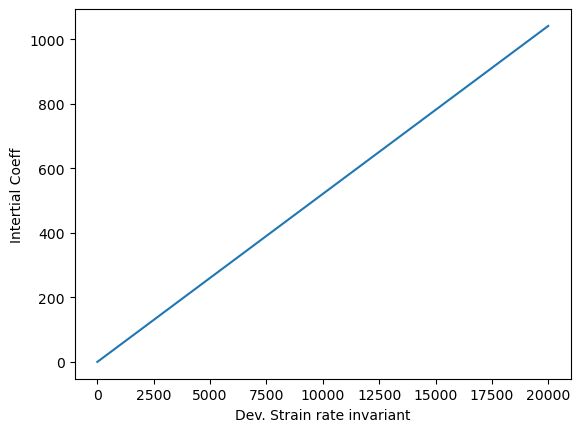

In [59]:
eps_q_rate=  np.linspace(0.001, 20000, 100)

# Representative Particle diameter 
D = 0.32e-3 #[m]
rho_solid = 2650 #[kg/m^3]
eff_mean_stress = 0.1 # [N/m^2] 

intertial_coeff = calc_intertial_coeff(D, eps_q_rate, rho_solid, mean_stress=eff_mean_stress)

fig, axs = plt.subplots(nrows = 1, ncols = 1)

axs = np.atleast_1d(axs)

axs[0].plot(eps_q_rate, intertial_coeff)

axs[0].set_xlabel("Dev. Strain rate invariant")
axs[0].set_ylabel("Intertial Coeff")

In [62]:
ref_coeff = 2e-5
intertial_coeff = np.linspace(ref_coeff, 1000, 100)

G_0 = 10000
init_poisson_ratio = 0.2

# Set the rate coefficients
kG = 0.04
kK = 2.5 * kG

# Calc the initial bulk modulus
K_0 = calc_bulk_modulus(init_poisson_ratio, G_0)

print(f"Initial bulk modulus: {K_0:.2f} [kPa]")

# Calc the updated parameters
G_rate = calc_updated_G(intertial_coeff, ref_coeff, G_0, kG)

K_rate= calc_updated_K(intertial_coeff, ref_coeff, K_0, kK)

# Calc the poisson ratio from the updated parameters
poisson_rate = calc_poisson_ratio(K_rate, G_rate)

Initial bulk modulus: 13333.33 [kPa]


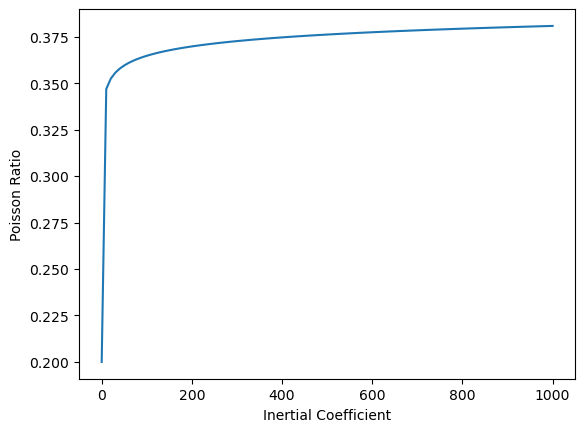

In [63]:
# Plot the poisson ratio vs. the intertial coefficient
fig, axs = plt.subplots(nrows = 1, ncols = 1)

axs = np.atleast_1d(axs)

axs[0].plot(intertial_coeff, poisson_rate)

axs[0].set_xlabel("Inertial Coefficient")
axs[0].set_ylabel("Poisson Ratio")

plt.show()